In [5]:
import pandas as pd
import joblib

df_raw = pd.read_csv('../data/processed/train_balanced.csv')
print(df_raw.shape)
print(df_raw.columns.tolist())
print(df_raw.iloc[:, -1].value_counts())

(58456, 45)
['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'contacted_before', 'campaign_intensity', 'has_loan_or_housing', 'y']
y
0    29228
1    29228
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Muestra para CV (SVM no escala bien)
X_sample = X.sample(n=10000, random_state=42)
y_sample = y[X_sample.index]

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    print(f"Evaluando {name}...")
    X_cv = X_sample if name == 'SVM' else X
    y_cv = y_sample if name == 'SVM' else y
    scores = cross_validate(model, X_cv, y_cv, cv=cv, scoring=scoring)
    results[name] = {m: f"{scores[f'test_{m}'].mean():.4f} ± {scores[f'test_{m}'].std():.4f}" for m in scoring}

df_results = pd.DataFrame(results).T
print(df_results)

Evaluando Logistic Regression...
Evaluando Decision Tree...
Evaluando Random Forest...
Evaluando SVM...
Evaluando KNN...


c:\Users\Marcelo\miniforge3\envs\environment\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


                            accuracy        precision           recall  \
Logistic Regression  0.7623 ± 0.0030  0.8087 ± 0.0039  0.6871 ± 0.0035   
Decision Tree        0.9007 ± 0.0008  0.8953 ± 0.0019  0.9075 ± 0.0015   
Random Forest        0.9426 ± 0.0011  0.9492 ± 0.0022  0.9352 ± 0.0018   
SVM                  0.7764 ± 0.0078  0.8211 ± 0.0098  0.7224 ± 0.0219   
KNN                  0.8619 ± 0.0021  0.8235 ± 0.0036  0.9212 ± 0.0032   

                                  f1          roc_auc  
Logistic Regression  0.7429 ± 0.0032  0.8276 ± 0.0014  
Decision Tree        0.9014 ± 0.0007  0.9018 ± 0.0010  
Random Forest        0.9422 ± 0.0011  0.9827 ± 0.0010  
SVM                  0.7683 ± 0.0110  0.8586 ± 0.0047  
KNN                  0.8696 ± 0.0018  0.9305 ± 0.0019  



Logistic Regression
              precision    recall  f1-score   support

          No       0.94      0.84      0.89      7307
         Yes       0.32      0.61      0.42       927

    accuracy                           0.81      8234
   macro avg       0.63      0.72      0.65      8234
weighted avg       0.87      0.81      0.83      8234


Decision Tree
              precision    recall  f1-score   support

          No       0.92      0.91      0.91      7307
         Yes       0.32      0.34      0.33       927

    accuracy                           0.84      8234
   macro avg       0.62      0.63      0.62      8234
weighted avg       0.85      0.84      0.85      8234


Random Forest
              precision    recall  f1-score   support

          No       0.92      0.95      0.94      7307
         Yes       0.49      0.35      0.41       927

    accuracy                           0.89      8234
   macro avg       0.70      0.65      0.67      8234
weighted avg       0.87

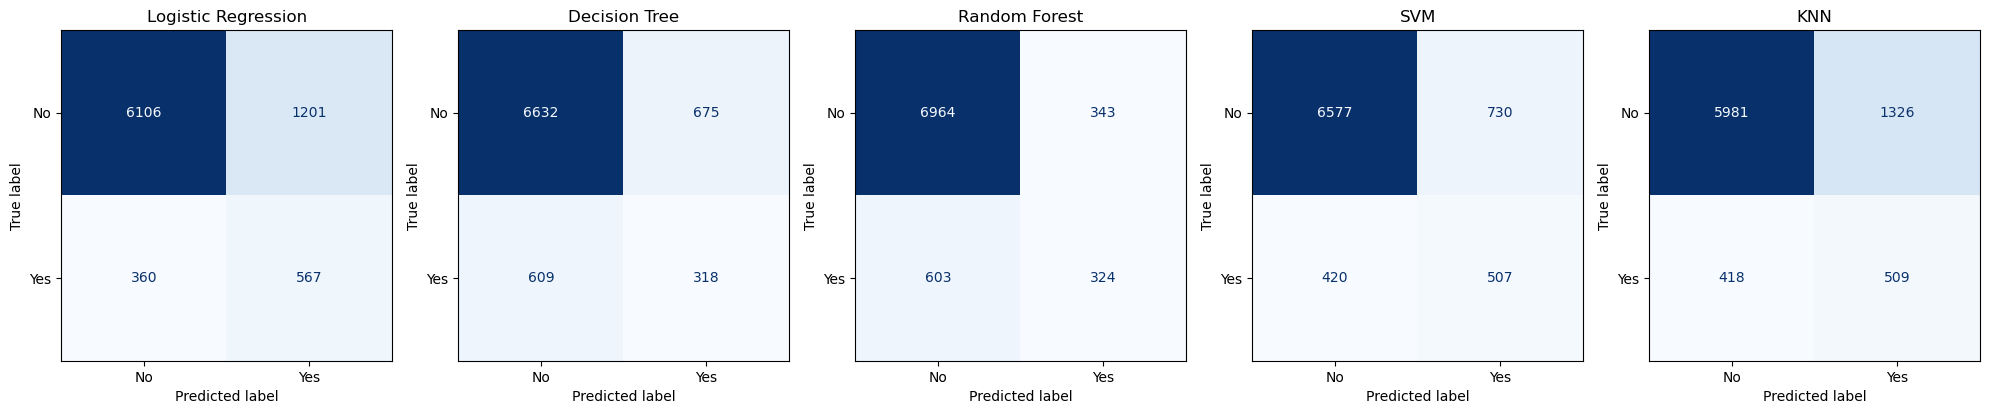

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_test = pd.read_csv('../data/processed/test_original.csv')
X_test = df_test.drop(columns='y')
y_test = df_test['y']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}\n{name}")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['No', 'Yes'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

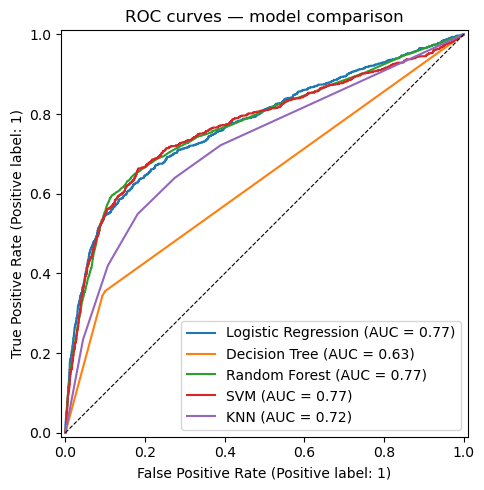

In [11]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC curves — model comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

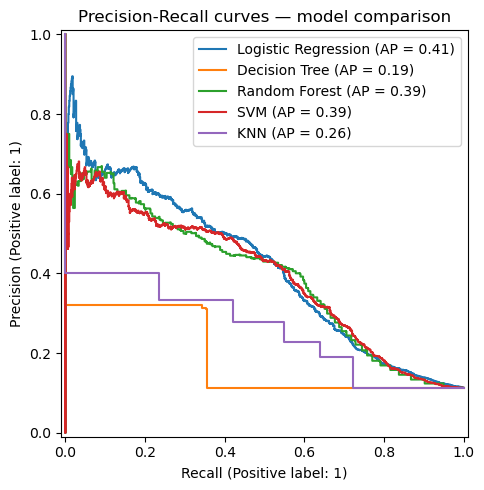

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('Precision-Recall curves — model comparison')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()